Load & inspect JSON files

In [18]:
import sys
print(sys.executable)

c:\Users\cavan\OneDrive\Desktop\NUS\LAST SEM\DSA4264\project\projvenv\Scripts\python.exe


In [4]:
import html
import json
import re
import sys
import unicodedata
from collections import Counter
from pathlib import Path

import pandas as pd
import nltk
from nltk.corpus import stopwords


# Download stopwords (only needed once)
# nltk.download("stopwords")

# Resolve project root whether the notebook is opened from repo root or notebooks/
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

DATA_DIR_CANDIDATES = [
    PROJECT_ROOT / "data",
    PROJECT_ROOT / "proj data" / "data",
]

files = []
for data_dir in DATA_DIR_CANDIDATES:
    if data_dir.exists():
        files.extend(sorted(data_dir.glob("*.json")))

print(f"Found {len(files)} JSON files")
for data_dir in DATA_DIR_CANDIDATES:
    count = len(list(data_dir.glob("*.json"))) if data_dir.exists() else 0
    print(f"- {data_dir}: {count}")

if not files:
    raise FileNotFoundError(f"No JSON files found in candidates: {DATA_DIR_CANDIDATES}")

files[:5]  # Show first 5


Found 0 JSON files
- /Users/arthurchong/Desktop/DSA4264-text-group-4/data: 0
- /Users/arthurchong/Desktop/DSA4264-text-group-4/proj data/data: 0


FileNotFoundError: No JSON files found in candidates: [PosixPath('/Users/arthurchong/Desktop/DSA4264-text-group-4/data'), PosixPath('/Users/arthurchong/Desktop/DSA4264-text-group-4/proj data/data')]

Flat Dataframe 

In [3]:
def _strip_html(raw):
    text = re.sub(r"<[^>]+>", " ", str(raw or ""))
    return html.unescape(text)


def clean_text_for_pipeline(raw):
    text = _strip_html(raw)
    cleaned_chars = []
    for char in text:
        if unicodedata.category(char).startswith("S"):
            continue
        cleaned_chars.append(char)
    text = "".join(cleaned_chars).lower()
    text = re.sub(r"[^a-z0-9\s\+\#]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def _extract_first_category(categories):
    if isinstance(categories, list) and categories:
        first = categories[0]
        if isinstance(first, dict):
            value = str(first.get("category") or first.get("name") or "Unknown").strip()
            return value if value else "Unknown"
        if isinstance(first, str):
            return first.strip() if first.strip() else "Unknown"
    return "Unknown"


def load_job(fp):
    with open(fp, "r", encoding="utf-8") as f:
        j = json.load(f)

    category = _extract_first_category(j.get("categories", []))
    skills = [
        str(s.get("skill")).strip()
        for s in j.get("skills", [])
        if isinstance(s, dict) and str(s.get("skill", "")).strip()
    ]

    return {
        "job_id": j.get("metadata", {}).get("jobPostId") or j.get("uuid"),
        "title": j.get("title"),
        "description": j.get("description"),
        "description_clean": clean_text_for_pipeline(j.get("description")),
        "category": category,
        "primary_category": category,
        "min_salary": j.get("salary", {}).get("minimum"),
        "max_salary": j.get("salary", {}).get("maximum"),
        "experience_years": j.get("minimumYearsExperience"),
        "ssec_eqa": str(j.get("ssecEqa") or "").strip(),
        "ssoc_code": str(j.get("ssocCode") or "").strip(),
        "employment_type": j.get("employmentTypes", [{}])[0].get("employmentType"),
        "position_level": j.get("positionLevels", [{}])[0].get("position"),
        "company": j.get("postedCompany", {}).get("name"),
        "skills": skills,
    }


rows = [load_job(fp) for fp in files]
df = pd.DataFrame(rows)

print(f"Loaded jobs: {len(df)}")
print("Columns:", sorted(df.columns))
df.head()


Loaded jobs: 22720
Columns: ['category', 'company', 'description', 'description_clean', 'employment_type', 'experience_years', 'job_id', 'max_salary', 'min_salary', 'position_level', 'primary_category', 'skills', 'ssec_eqa', 'ssoc_code', 'title']


,job_id,title,description,description_clean,category,primary_category,min_salary,max_salary,experience_years,ssec_eqa,ssoc_code,employment_type,position_level,company,skills
0,ATS-2026-0184172,"Assistant Manager, Corporate Communications",<p><strong>Job Summary: </strong></p><p>This r...,job summary this role supports the corporate c...,Marketing / Public Relations,Marketing / Public Relations,5500,7500,3,70,24320,Permanent,Junior Executive,CITY DEVELOPMENTS LIMITED,"[Multimedia, Social Media, Strategic Communica..."
1,ATS-2026-0190206,Manager (Facilities Management),<p><strong >Role Overview</strong></p><p>We ar...,role overview we are seeking a facilities mana...,Real Estate / Property Management,Real Estate / Property Management,7000,9000,8,70,12191,Permanent,Manager,NTUC FAIRPRICE CO-OPERATIVE LTD,"[Fire Safety, Management Skills, Sustainabilit..."
2,MCF-2025-1100407,Sales Administrator,<ul>\n <li>Serve as administrator / key opera...,serve as administrator key operator for all sa...,Hospitality,Hospitality,3000,3200,1,69,33224,Full Time,Executive,THE FULLERTON HOTEL,"[Sales, Microsoft Office, Microsoft Excel, Tra..."
3,MCF-2025-1103608,Assistant Field Engineer(Construction),<h3><strong>Our Company:</strong></h3>\n<p>Our...,our company our company develops ict informati...,Customer Service,Customer Service,2500,4500,1,51,21499,Full Time,Fresh/entry level,"ENZAN KOUBOU CO., LTD. Singapore Branch","[Troubleshooting, Construction, Hardware, Elec..."
4,MCF-2025-1105270,Electronic Keyboard Teacher,<ul>\n <li>Teaching lessons to students at al...,teaching lessons to students at all skill leve...,Education and Training,Education and Training,2500,3500,1,69,36204,Full Time,Non-executive,SYMPHONY MUSIC SCHOOL,"[Piano, Classical, Microsoft Excel, Teaching, ..."


Job Titles

In [4]:
(
    df["title"]
    .str.lower()
    .value_counts()
)


title
supervisor                                                            325
quantity surveyor                                                     107
chef                                                                   88
project manager                                                        77
manager                                                                77
                                                                     ... 
⚡🌟 sales consultant - entry level 🌟                                     1
sales executive (manufacturing / construction - training provided)      1
⚡⚡️ entry-level sales executive ⚡️                                      1
⚡🌟 sales advisor – entry level 🌟                                        1
⚡🚀 sales executive – entry level 🚀                                      1
Name: count, Length: 14530, dtype: int64

In [5]:
import unicodedata

# Remove emojis from job titles
def remove_emojis(text):
    if not isinstance(text, str):
        return ""
    # Remove emojis and other unicode symbols
    return ''.join(
        char for char in text 
        if unicodedata.category(char)[0] != 'S'  # 'S' = Symbol category
    ).strip()

# Clean titles by removing emojis and converting to lowercase
df["title_cleaned"] = df["title"].apply(remove_emojis).str.lower()

# Show cleaned job titles and their counts
print("Cleaned Job Titles:")
print(df["title_cleaned"].value_counts())
print("\n" + "="*50 + "\n")

# Count titles that include the word "entry"
entry_titles = df[df["title_cleaned"].str.contains("entry", na=False)]["title_cleaned"].value_counts()
print("Titles containing 'entry':")
print(f"Total count: {len(df[df['title_cleaned'].str.contains('entry', na=False)])}")
print(entry_titles)


Cleaned Job Titles:
title_cleaned
supervisor                                                            325
quantity surveyor                                                     107
chef                                                                   88
project manager                                                        77
manager                                                                77
                                                                     ... 
sales consultant - entry level                                          1
sales executive (manufacturing / construction - training provided)      1
️ entry-level sales executive ️                                         1
sales advisor – entry level                                             1
sales executive – entry level                                           1
Name: count, Length: 14489, dtype: int64


Titles containing 'entry':
Total count: 595
title_cleaned
marketing and sales trainee (entry level)    48
eve

In [6]:
# Years of Experience
print("Years of Experience:")
print(df["experience_years"].value_counts().sort_index())
print(f"\nTotal jobs: {len(df)}")
print(f"Null values: {df['experience_years'].isna().sum()}")


Years of Experience:
experience_years
0     4109
1     5368
2     4186
3     3544
4      650
5     2844
6      416
7      224
8      601
9       29
10     563
11       4
12      55
13       2
14       2
15      98
16       1
17       1
18       1
20      19
25       2
30       1
Name: count, dtype: int64

Total jobs: 22720
Null values: 0


In [7]:
# Cleaned titles for 0 years experience
entry_level_titles = df[df["experience_years"] == 0]["title_cleaned"]
print("Entry-level (0 years experience) job titles:")
print(entry_level_titles.value_counts())
print(f"\nTotal entry-level positions: {len(entry_level_titles)}")


Entry-level (0 years experience) job titles:
title_cleaned
marketing and sales trainee (entry level)     48
junior sales and marketing representative     35
events management                             30
event and marketing (entry level)             30
marketing trainee (no experience required)    22
                                              ..
sales trainee – fresh graduates & ord          1
sales consultant - entry level                 1
️ entry-level sales executive ️                1
sales advisor – entry level                    1
sales executive – entry level                  1
Name: count, Length: 2619, dtype: int64

Total entry-level positions: 4109


In [8]:
# Filter dataframe for 0 years experience
df_entry_level = df[df["experience_years"] == 0]


Sectors/Categories

In [9]:
df_entry_level["category"].value_counts()


category
Marketing / Public Relations         746
Customer Service                     683
Events / Promotions                  415
Admin / Secretarial                  290
Advertising / Media                  244
Sales / Retail                       193
Healthcare / Pharmaceutical          157
Engineering                          152
F&B                                  145
Banking and Finance                  137
Education and Training               111
Manufacturing                        100
Building and Construction             77
Consulting                            74
General Work                          60
Logistics / Supply Chain              54
Accounting / Auditing / Taxation      47
Sciences / Laboratory / R&D           47
Environment / Health                  40
Information Technology                39
Human Resources                       38
Others                                37
Wholesale Trade                       37
General Management                    29
Medical

Skills

In [10]:
all_skills_entry = df_entry_level.explode("skills")["skills"]
all_skills_entry.value_counts()

all_skills_entry.value_counts().head(15)

(
    df_entry_level.explode("skills")
      .groupby("category")["skills"]
      .value_counts()
      .groupby(level=0)
      .head(5)
)


category                          skills          
Accounting / Auditing / Taxation  Accounting          33
                                  Microsoft Office    27
                                  Microsoft Excel     27
                                  Audit               26
                                  Team Player         18
                                                      ..
Wholesale Trade                   Inventory           37
                                  Microsoft Excel     35
                                  Market Research     34
                                  Commodity           34
                                  Sourcing            34
Name: count, Length: 210, dtype: int64

Text EDA (Simple NLP)

In [11]:
def clean_text(s):
    if not isinstance(s, str):
        return ""
    s = re.sub(r"<[^>]+>", " ", s)  # remove HTML
    s = s.lower()
    s = re.sub(r"[^a-z\s]", " ", s)
    s = re.sub(r"\s+", " ", s)
    return s.strip()

df_entry_level["clean_desc"] = df_entry_level["description"].apply(clean_text)

# Use NLTK's English stopwords
STOPWORDS = set(stopwords.words('english'))

words_entry = []
for text in df_entry_level["clean_desc"]:
    words_entry.extend([w for w in text.split() if w not in STOPWORDS and len(w) > 2])

Counter(words_entry).most_common(20)

[('team', 6117),
 ('work', 4379),
 ('experience', 4062),
 ('skills', 3235),
 ('sales', 3204),
 ('career', 2953),
 ('marketing', 2912),
 ('support', 2858),
 ('opportunities', 2550),
 ('learn', 2495),
 ('job', 2468),
 ('growth', 2429),
 ('apply', 2352),
 ('training', 2300),
 ('looking', 2027),
 ('grow', 2026),
 ('people', 2000),
 ('environment', 1988),
 ('requirements', 1974),
 ('customer', 1913)]

In [12]:
# Skills Breakdown for Entry-Level Jobs
print("Skills breakdown for entry-level (0 years) positions:")
print("\nJob ID | Title | Skills Array")
print("=" * 100)

# Create a clean view of jobs with their skills
entry_skills = df_entry_level[["job_id", "title_cleaned", "skills"]].copy()

# Display a sample
for idx, row in entry_skills.head(10).iterrows():
    print(f"\n{row['job_id']}")
    print(f"Title: {row['title_cleaned']}")
    print(f"Skills: {row['skills']}")

print("\n" + "=" * 100)
print(f"\nTotal entry-level jobs: {len(entry_skills)}")
print(f"Jobs with skills data: {entry_skills['skills'].apply(lambda x: len(x) > 0).sum()}")
print(f"Average skills per job: {entry_skills['skills'].apply(len).mean():.2f}")

# Verify skills are properly stored as arrays
print("\nSample skills array structure:")
print(entry_skills.iloc[0]['skills'])


Skills breakdown for entry-level (0 years) positions:

Job ID | Title | Skills Array

MCF-2025-1108112
Title: f&b executive
Skills: ['Microsoft Excel', 'Food Safety', 'Quality Assurance', 'Housekeeping', 'Interpersonal Skills', 'Inventory', 'Administration', 'Scheduling', 'Audit', 'Able To Work Independently']

MCF-2025-1121562
Title: outreach operations and data analysis executive
Skills: ['Tableau', 'Data Analysis', 'Big Data', 'Interpersonal Skills', 'Data Management', 'Service Level', 'MS Word', 'Attention to Detail', 'Excel', 'Statistics', 'Data Analytics', 'Power BI']

MCF-2025-1142940
Title: junior marketing crew - entry level/training provided
Skills: ['Communication', 'Customer Relationship', 'Sales', 'Teamwork', 'Leadership', 'Interpersonal Skills', 'Problem Solving', 'Marketing', 'Mentorship', 'Team Management', 'Time Management', 'Customer Services']

MCF-2025-1145527
Title: lpg gas delivery driver cum technician
Skills: ['Factory', 'Inventory', 'Unloading', 'Vehicles', 'Dr

In [13]:
# Top skills for entry-level positions
print("\nTop 25 Most Required Skills for Entry-Level Jobs:")
print("=" * 60)

# Explode the skills array to get each skill as a separate row
entry_level_exploded = df_entry_level.explode("skills")["skills"]
top_entry_skills = entry_level_exploded.value_counts().head(25)

for skill, count in top_entry_skills.items():
    print(f"{skill:<40} {count:>5} jobs ({count/len(entry_skills)*100:.1f}%)")

print(f"\nTotal unique skills required: {entry_level_exploded.nunique()}")



Top 25 Most Required Skills for Entry-Level Jobs:
Team Player                               2183 jobs (53.1%)
Leadership                                1754 jobs (42.7%)
Interpersonal Skills                      1647 jobs (40.1%)
Communication Skills                      1597 jobs (38.9%)
Marketing                                 1413 jobs (34.4%)
Sales                                     1370 jobs (33.3%)
Customer Service                          1311 jobs (31.9%)
Mentorship                                1089 jobs (26.5%)
Coaching                                   812 jobs (19.8%)
Brand Awareness                            693 jobs (16.9%)
Presentation Skills                        640 jobs (15.6%)
Management Skills                          615 jobs (15.0%)
Microsoft Excel                            564 jobs (13.7%)
Able To Work Independently                 563 jobs (13.7%)
Microsoft Office                           561 jobs (13.7%)
Selling                                    494 jo

In [14]:
# Top 10 skills by category for entry-level positions
print("Top 10 Skills by Category (Entry-Level, 0 Years Experience)")
print("=" * 80)

# Get unique categories
categories = df_entry_level["category"].unique()

for category in sorted(categories):
    print(f"\n{category.upper()}")
    print("-" * 80)
    
    # Filter by category
    category_jobs = df_entry_level[df_entry_level["category"] == category]
    
    # Explode skills for this category
    category_skills = category_jobs.explode("skills")["skills"]
    
    # Get top 10 skills
    top_10 = category_skills.value_counts().head(10)
    
    if len(top_10) == 0:
        print("No skills data available")
        continue
    
    # Display with count and percentage
    total_category_jobs = len(category_jobs)
    for rank, (skill, count) in enumerate(top_10.items(), 1):
        percentage = (count / total_category_jobs) * 100
        print(f"{rank:2d}. {skill:<40} {count:>4} ({percentage:>5.1f}%)")
    
    print(f"\n   Total jobs in category: {total_category_jobs}")


Top 10 Skills by Category (Entry-Level, 0 Years Experience)

ACCOUNTING / AUDITING / TAXATION
--------------------------------------------------------------------------------
 1. Accounting                                 33 ( 70.2%)
 2. Microsoft Office                           27 ( 57.4%)
 3. Microsoft Excel                            27 ( 57.4%)
 4. Audit                                      26 ( 55.3%)
 5. Team Player                                18 ( 38.3%)
 6. Financial Statements                       17 ( 36.2%)
 7. Interpersonal Skills                       15 ( 31.9%)
 8. Able To Work Independently                 14 ( 29.8%)
 9. Tax                                        14 ( 29.8%)
10. Compliance                                 13 ( 27.7%)

   Total jobs in category: 47

ADMIN / SECRETARIAL
--------------------------------------------------------------------------------
 1. Administration                            151 ( 52.1%)
 2. Microsoft Office                       

Role Cluster + SSOC5 Breakdown (Project Logic)


In [17]:
from module_readiness.config.settings import read_yaml_json
from module_readiness.processing.role_families import assign_role_families

role_rules = read_yaml_json(PROJECT_ROOT / "config" / "role_family_rules.yaml")
cluster_rules = read_yaml_json(PROJECT_ROOT / "config" / "role_clusters.yaml")

# Use the same policy-relevant scope as the pipeline:
# experience <= 2 years and SSEC EQA = 70.
df_role_scope = df.copy()
df_role_scope = df_role_scope[df_role_scope["experience_years"].notna()].copy()
df_role_scope = df_role_scope[df_role_scope["experience_years"] <= 2].copy()
df_role_scope = df_role_scope[df_role_scope["ssec_eqa"] == "70"].copy()

role_result = assign_role_families(
    jobs=df_role_scope,
    role_rules=role_rules,
    cluster_rules=cluster_rules,
)
df_role = role_result.jobs.copy()

print(f"Scope rows for role/SSOC analysis: {len(df_role)}")
print(f"Unique role clusters: {df_role['role_cluster'].nunique()}")
print(f"Unique SSOC5 codes: {df_role.loc[df_role['ssoc_5d'] != '', 'ssoc_5d'].nunique()}")

pd.Series(role_result.diagnostics).sort_index()


ModuleNotFoundError: No module named 'loguru'

Role-Cluster Assignment Coverage


In [ ]:
denominator = max(len(df_role), 1)

coverage_summary = pd.DataFrame(
    {
        "metric": [
            "rows_in_scope",
            "rows_with_ssoc5",
            "rows_with_ssoc4",
            "unique_role_clusters",
            "unique_ssoc5",
            "unique_ssoc4",
        ],
        "value": [
            len(df_role),
            int((df_role["ssoc_5d"] != "").sum()),
            int((df_role["ssoc_4d"] != "").sum()),
            int(df_role["role_cluster"].nunique()),
            int(df_role.loc[df_role["ssoc_5d"] != "", "ssoc_5d"].nunique()),
            int(df_role.loc[df_role["ssoc_4d"] != "", "ssoc_4d"].nunique()),
        ],
    }
)

assignment_source_breakdown = (
    df_role["role_cluster_source"]
    .value_counts(dropna=False)
    .rename_axis("role_cluster_source")
    .reset_index(name="jobs")
)
assignment_source_breakdown["share_pct"] = (
    assignment_source_breakdown["jobs"] / denominator * 100
).round(2)

coverage_summary, assignment_source_breakdown


Role Cluster Breakdown


In [ ]:
role_cluster_breakdown = (
    df_role.groupby(["role_cluster", "broad_family"], dropna=False)
    .agg(
        jobs=("job_id", "count"),
        unique_ssoc5=("ssoc_5d", "nunique"),
        unique_ssoc4=("ssoc_4d", "nunique"),
        median_min_salary=("min_salary", "median"),
        median_max_salary=("max_salary", "median"),
    )
    .sort_values("jobs", ascending=False)
)
role_cluster_breakdown["share_pct"] = (
    role_cluster_breakdown["jobs"] / denominator * 100
).round(2)

role_cluster_breakdown.reset_index()


SSOC5 Breakdown


In [ ]:
ssoc5_breakdown = (
    df_role[df_role["ssoc_5d"] != ""]
    .groupby(["ssoc_5d", "ssoc_5d_name", "role_cluster"], dropna=False)
    .agg(jobs=("job_id", "count"))
    .reset_index()
    .sort_values("jobs", ascending=False)
)
ssoc5_breakdown["share_pct"] = (ssoc5_breakdown["jobs"] / denominator * 100).round(2)

ssoc5_breakdown.head(30)


In [ ]:
ssoc5_within_cluster = (
    df_role[df_role["ssoc_5d"] != ""]
    .groupby(["role_cluster", "ssoc_5d", "ssoc_5d_name"], dropna=False)
    .size()
    .rename("jobs")
    .reset_index()
)

cluster_sizes = (
    df_role.groupby("role_cluster")
    .size()
    .rename("cluster_jobs")
    .reset_index()
)

ssoc5_within_cluster = ssoc5_within_cluster.merge(cluster_sizes, on="role_cluster", how="left")
ssoc5_within_cluster["within_cluster_pct"] = (
    ssoc5_within_cluster["jobs"] / ssoc5_within_cluster["cluster_jobs"] * 100
).round(2)

top_ssoc5_per_cluster = (
    ssoc5_within_cluster
    .sort_values(["role_cluster", "jobs", "ssoc_5d"], ascending=[True, False, True])
    .groupby("role_cluster", as_index=False)
    .head(5)
)

top_ssoc5_per_cluster


In [ ]:
top_clusters = role_cluster_breakdown.head(10).index.get_level_values("role_cluster").tolist()
top_ssoc5_codes = (
    df_role[df_role["ssoc_5d"] != ""]
    .groupby("ssoc_5d")
    .size()
    .sort_values(ascending=False)
    .head(15)
    .index
    .tolist()
)

cluster_ssoc5_matrix = pd.crosstab(df_role["role_cluster"], df_role["ssoc_5d"])
cluster_ssoc5_matrix = cluster_ssoc5_matrix.reindex(
    index=top_clusters,
    columns=top_ssoc5_codes,
    fill_value=0,
)

ssoc5_name_map = (
    df_role[df_role["ssoc_5d"] != ""]
    .drop_duplicates(subset=["ssoc_5d"])
    .set_index("ssoc_5d")["ssoc_5d_name"]
    .to_dict()
)
cluster_ssoc5_matrix.columns = [f"{code} | {ssoc5_name_map.get(code, '')}" for code in cluster_ssoc5_matrix.columns]

cluster_ssoc5_matrix


Category + Skills Breakdown by Role Cluster


In [ ]:
category_cluster_matrix = pd.crosstab(df_role["primary_category"], df_role["role_cluster"])
top_categories = category_cluster_matrix.sum(axis=1).sort_values(ascending=False).head(15).index

category_cluster_matrix.loc[top_categories]


In [ ]:
skills_long = (
    df_role.explode("skills")
    .dropna(subset=["skills"])
    .assign(skills=lambda d: d["skills"].astype(str).str.strip())
)
skills_long = skills_long[skills_long["skills"] != ""]

top_skills_by_cluster = (
    skills_long.groupby(["role_cluster", "skills"], dropna=False)
    .size()
    .rename("jobs")
    .reset_index()
    .sort_values(["role_cluster", "jobs", "skills"], ascending=[True, False, True])
    .groupby("role_cluster", as_index=False)
    .head(10)
)
top_skills_by_cluster = top_skills_by_cluster.merge(cluster_sizes, on="role_cluster", how="left")
top_skills_by_cluster["within_cluster_pct"] = (
    top_skills_by_cluster["jobs"] / top_skills_by_cluster["cluster_jobs"] * 100
).round(2)

top_skills_by_cluster


Retrieval Label Evaluation

This section analyses `outputs/retrieval_labels_test.csv`, where each row is a retrieved `(module, job)` pair with a manually assigned `relevance` label. The goal is to inspect the relevance-score distribution across modules and identify which modules the retrieval model performs poorly on versus which ones it performs better on.

In [9]:
from pathlib import Path
from IPython.display import display

import matplotlib.pyplot as plt

try:
    PROJECT_ROOT
except NameError:
    PROJECT_ROOT = Path.cwd()
    if not (PROJECT_ROOT / "src").exists():
        PROJECT_ROOT = PROJECT_ROOT.parent

RETRIEVAL_LABELS_PATH = PROJECT_ROOT / "outputs" / "retrieval_label_pool_200_top20_union_scored.csv"

retrieval_df = pd.read_csv(RETRIEVAL_LABELS_PATH)
retrieval_df["relevance"] = pd.to_numeric(retrieval_df["relevance"], errors="coerce")

module_label_df = retrieval_df.dropna(subset=["relevance"]).copy()
module_label_df["relevance"] = module_label_df["relevance"].astype(int)

print(f"Loaded {len(module_label_df):,} labelled retrieval pairs from {RETRIEVAL_LABELS_PATH.relative_to(PROJECT_ROOT)}")
print("Overall relevance distribution:")
display(module_label_df["relevance"].value_counts().sort_index().rename("pairs").to_frame())

module_label_df[[
    "module_code",
    "module_title",
    "job_title",
    "company",
    "hybrid_rank",
    "hybrid_rrf_score",
    "relevance",
]].head()

Loaded 7,715 labelled retrieval pairs from outputs/retrieval_label_pool_200_top20_union_scored.csv
Overall relevance distribution:


,pairs
relevance,
0,2397
1,3344
2,1852
3,122


,module_code,module_title,job_title,company,hybrid_rank,hybrid_rrf_score,relevance
0,GEC1003,"Pirates, Oceans and the Maritime World",System Engineer,GNA ENGINEERING PTE. LTD.,1.0,1.000000,0
1,GEC1003,"Pirates, Oceans and the Maritime World",Assistant Curator,SINGAPORE CHINESE CULTURAL CENTRE,4.0,0.897275,1
2,GEC1003,"Pirates, Oceans and the Maritime World",Trainee Shipbroker,ANGLE RECRUITMENT PTE. LTD.,NaN,0.575015,0
3,GEC1003,"Pirates, Oceans and the Maritime World",Applied AI Associate - Ocean Transportation,CARGILL OCEAN TRANSPORTATION (SINGAPORE) PTE. ...,2.0,0.962510,0
4,GEC1003,"Pirates, Oceans and the Maritime World",Trainee Shipbroker,ANGLE RECRUITMENT PTE. LTD.,NaN,0.565967,0


Module-Level Relevance Distribution

The table below shows, for every module, how many retrieved jobs ended up with each manual relevance score. The stacked bar chart is the same information normalised into shares, which makes it easier to compare modules with slightly different numbers of retrieved pairs.

,module_code,module_title,retrieved_pairs,avg_relevance,relevance_0,share_0,relevance_1,share_1,relevance_2,share_2,relevance_3,share_3,high_relevance_share,low_relevance_share
0,BT4013,Analytics for Capital Market Trading and Inves...,27,2.444,0,0.000,5,0.185,5,0.185,17,0.630,0.815,0.000
1,TCE4282,Building Information Modeling for Project Mana...,28,2.357,0,0.000,1,0.036,16,0.571,11,0.393,0.964,0.000
2,SA4110,Machine Learning Application Development,34,2.147,0,0.000,5,0.147,19,0.559,10,0.294,0.853,0.000
3,MKT1705,Principles of Marketing,33,1.939,0,0.000,2,0.061,31,0.939,0,0.000,0.939,0.000
4,SA4105,Web Application Development,34,1.853,0,0.000,9,0.265,21,0.618,4,0.118,0.735,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,NEX3003,GEx New York,42,0.024,41,0.976,1,0.024,0,0.000,0,0.000,0.000,0.976
196,CFG2101,NUS Vacation Internship Programme,40,0.000,40,1.000,0,0.000,0,0.000,0,0.000,0.000,1.000
197,SA4107,Industrial Attachment Project,40,0.000,40,1.000,0,0.000,0,0.000,0,0.000,0.000,1.000
198,TG3001,Industrial Practice,42,0.000,42,1.000,0,0.000,0,0.000,0,0.000,0.000,1.000


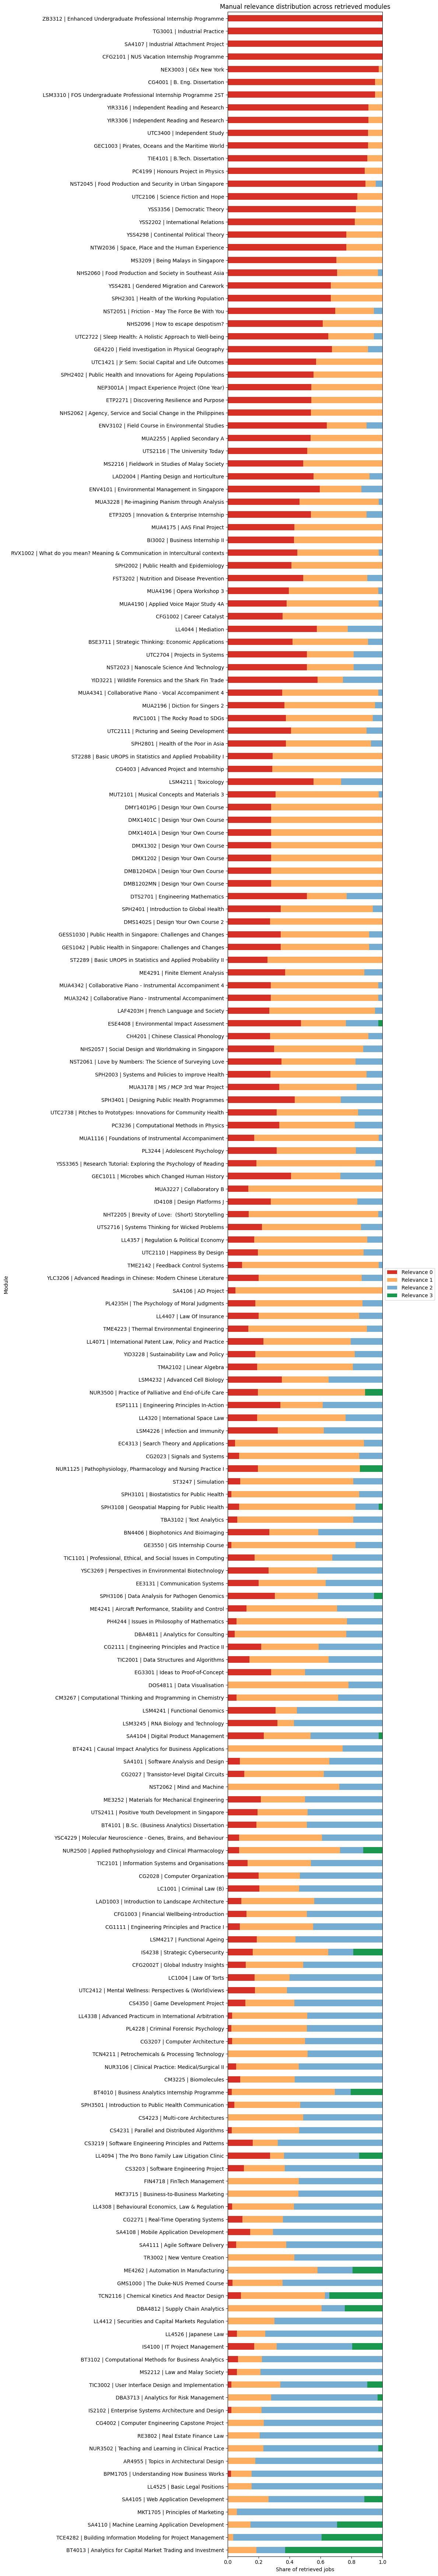

Top modules by count of relevance = 0 labels


,module_code,module_title,retrieved_pairs,relevance_0,share_0,avg_relevance
198,TG3001,Industrial Practice,42,42,1.000,0.000
195,NEX3003,GEx New York,42,41,0.976,0.024
186,NST2045,Food Production and Security in Urban Singapore,46,41,0.891,0.152
196,CFG2101,NUS Vacation Internship Programme,40,40,1.000,0.000
197,SA4107,Industrial Attachment Project,40,40,1.000,0.000
199,ZB3312,Enhanced Undergraduate Professional Internship...,40,40,1.000,0.000
194,CG4001,B. Eng. Dissertation,42,40,0.952,0.048
191,YIR3306,Independent Reading and Research,44,40,0.909,0.091
192,YIR3316,Independent Reading and Research,44,40,0.909,0.091
193,LSM3310,FOS Undergraduate Professional Internship Prog...,41,39,0.951,0.049


Top modules by count of relevance = 1 labels


,module_code,module_title,retrieved_pairs,relevance_1,share_1,avg_relevance
107,MUA3227,Collaboratory B,45,39,0.867,0.867
101,TME2142,Feedback Control Systems,43,38,0.884,0.930
99,SA4106,AD Project,39,37,0.949,0.949
87,EC4313,Search Theory and Applications,42,35,0.833,1.071
83,SPH3101,Biostatistics for Public Health,40,33,0.825,1.125
111,MUA1116,Foundations of Instrumental Accompaniment,41,33,0.805,0.854
109,YSS3365,Research Tutorial: Exploring the Psychology of...,43,33,0.767,0.860
79,GE3550,GIS Internship Course,40,32,0.800,1.150
68,DOS4811,Data Visualisation,41,32,0.780,1.220
140,CG4003,Advanced Project and Internship,45,32,0.711,0.711


Top modules by count of relevance = 2 labels


,module_code,module_title,retrieved_pairs,relevance_2,share_2,avg_relevance
6,BPM1705,Understanding How Business Works,45,38,0.844,1.822
15,BT3102,Computational Methods for Business Analytics,45,35,0.778,1.711
10,CG4002,Computer Engineering Capstone Project,43,33,0.767,1.767
11,IS2102,Enterprise Systems Architecture and Design,41,32,0.780,1.756
3,MKT1705,Principles of Marketing,33,31,0.939,1.939
8,NUR3502,Teaching and Learning in Clinical Practice,39,29,0.744,1.795
25,SA4108,Mobile Application Development,41,29,0.707,1.561
26,CG2271,Real-Time Operating Systems,42,27,0.643,1.548
14,MS2212,Law and Malay Society,33,26,0.788,1.727
17,LL4526,Japanese Law,33,25,0.758,1.697


Top modules by count of relevance = 3 labels


,module_code,module_title,retrieved_pairs,relevance_3,share_3,avg_relevance
0,BT4013,Analytics for Capital Market Trading and Inves...,27,17,0.630,2.444
20,TCN2116,Chemical Kinetics And Reactor Design,35,12,0.343,1.629
1,TCE4282,Building Information Modeling for Project Mana...,28,11,0.393,2.357
2,SA4110,Machine Learning Application Development,34,10,0.294,2.147
19,DBA4812,Supply Chain Analytics,33,8,0.242,1.636
36,BT4010,Business Analytics Internship Programme,39,8,0.205,1.487
16,IS4100,IT Project Management,41,8,0.195,1.707
47,IS4238,Strategic Cybersecurity,37,7,0.189,1.378
22,ME4262,Automation In Manufacturing,31,6,0.194,1.613
85,NUR1125,"Pathophysiology, Pharmacology and Nursing Prac...",41,6,0.146,1.098


In [10]:
module_keys = ["module_code", "module_title"]
score_cols = [f"relevance_{score}" for score in [0, 1, 2, 3]]
share_cols = [f"share_{score}" for score in [0, 1, 2, 3]]

module_counts = (
    module_label_df.groupby(module_keys + ["relevance"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=[0, 1, 2, 3], fill_value=0)
)
module_counts.columns = score_cols

module_summary = module_counts.join(
    module_label_df.groupby(module_keys)["relevance"].mean().rename("avg_relevance")
).reset_index()
module_summary["retrieved_pairs"] = module_summary[score_cols].sum(axis=1)

for score in [0, 1, 2, 3]:
    module_summary[f"share_{score}"] = module_summary[f"relevance_{score}"] / module_summary["retrieved_pairs"]

module_summary["high_relevance_share"] = (
    module_summary["relevance_2"] + module_summary["relevance_3"]
) / module_summary["retrieved_pairs"]
module_summary["low_relevance_share"] = module_summary["relevance_0"] / module_summary["retrieved_pairs"]
module_summary["module_label"] = module_summary["module_code"] + " | " + module_summary["module_title"]

module_summary = module_summary.sort_values(
    ["avg_relevance", "high_relevance_share", "module_code"],
    ascending=[False, False, True],
).reset_index(drop=True)

module_distribution = module_summary[[
    "module_code",
    "module_title",
    "retrieved_pairs",
    "avg_relevance",
    "relevance_0",
    "share_0",
    "relevance_1",
    "share_1",
    "relevance_2",
    "share_2",
    "relevance_3",
    "share_3",
    "high_relevance_share",
    "low_relevance_share",
]].copy()
module_distribution[["avg_relevance", *share_cols, "high_relevance_share", "low_relevance_share"]] = (
    module_distribution[["avg_relevance", *share_cols, "high_relevance_share", "low_relevance_share"]].round(3)
)

display(module_distribution)

ax = (
    module_summary.set_index("module_label")[share_cols]
    .rename(columns={
        "share_0": "Relevance 0",
        "share_1": "Relevance 1",
        "share_2": "Relevance 2",
        "share_3": "Relevance 3",
    })
    .plot(
        kind="barh",
        stacked=True,
        figsize=(12, max(10, len(module_summary) * 0.35)),
        color=["#d73027", "#fdae61", "#74add1", "#1a9850"],
    )
)
ax.set_title("Manual relevance distribution across retrieved modules")
ax.set_xlabel("Share of retrieved jobs")
ax.set_ylabel("Module")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.show()

for score in [0, 1, 2, 3]:
    print(f"Top modules by count of relevance = {score} labels")
    display(
        module_summary.sort_values(
            [f"relevance_{score}", f"share_{score}", "retrieved_pairs"],
            ascending=[False, False, False],
        )[[
            "module_code",
            "module_title",
            "retrieved_pairs",
            f"relevance_{score}",
            f"share_{score}",
            "avg_relevance",
        ]]
        .head(10)
        .assign(**{f"share_{score}": lambda d: d[f"share_{score}"].round(3), "avg_relevance": lambda d: d["avg_relevance"].round(3)})
    )

Modules The Model Did Poorly On vs Better On

Here, `poorly` means the module has a low mean manual relevance and a high share of `relevance = 0` labels among its retrieved jobs. `Better` means the module has a high mean manual relevance and a high share of `relevance >= 2` labels. Since `relevance = 3` is very rare in this file, the strongest modules are mostly driven by how often they achieve `relevance = 2`.

In [12]:
ranking_cols = [
    "module_code",
    "module_title",
    "retrieved_pairs",
    "avg_relevance",
    "relevance_0",
    "share_0",
    "relevance_1",
    "share_1",
    "relevance_2",
    "share_2",
    "relevance_3",
    "share_3",
    "high_relevance_share",
    "low_relevance_share",
]

poor_modules = module_summary.sort_values(
    ["avg_relevance", "low_relevance_share", "retrieved_pairs"],
    ascending=[True, False, False],
)[ranking_cols].head(10).copy()

better_modules = module_summary.sort_values(
    ["avg_relevance", "high_relevance_share", "retrieved_pairs"],
    ascending=[False, False, False],
)[ranking_cols].head(10).copy()

for frame in [poor_modules, better_modules]:
    frame[["avg_relevance", *share_cols, "high_relevance_share", "low_relevance_share"]] = (
        frame[["avg_relevance", *share_cols, "high_relevance_share", "low_relevance_share"]].round(3)
    )

print("Modules the model did poorly on")
display(poor_modules)

print("Modules the model did better on")
display(better_modules)

print("Modules that ever received a relevance = 3 label")
display(
    module_summary.loc[module_summary["relevance_3"] > 0, [
        "module_code",
        "module_title",
        "retrieved_pairs",
        "relevance_3",
        "share_3",
        "avg_relevance",
    ]]
    .sort_values(["relevance_3", "avg_relevance"], ascending=[False, False])
    .assign(share_3=lambda d: d["share_3"].round(3), avg_relevance=lambda d: d["avg_relevance"].round(3))
)

Modules the model did poorly on


,module_code,module_title,retrieved_pairs,avg_relevance,relevance_0,share_0,relevance_1,share_1,relevance_2,share_2,relevance_3,share_3,high_relevance_share,low_relevance_share
198,TG3001,Industrial Practice,42,0.000,42,1.000,0,0.000,0,0.0,0,0.0,0.0,1.000
196,CFG2101,NUS Vacation Internship Programme,40,0.000,40,1.000,0,0.000,0,0.0,0,0.0,0.0,1.000
197,SA4107,Industrial Attachment Project,40,0.000,40,1.000,0,0.000,0,0.0,0,0.0,0.0,1.000
199,ZB3312,Enhanced Undergraduate Professional Internship...,40,0.000,40,1.000,0,0.000,0,0.0,0,0.0,0.0,1.000
195,NEX3003,GEx New York,42,0.024,41,0.976,1,0.024,0,0.0,0,0.0,0.0,0.976
194,CG4001,B. Eng. Dissertation,42,0.048,40,0.952,2,0.048,0,0.0,0,0.0,0.0,0.952
193,LSM3310,FOS Undergraduate Professional Internship Prog...,41,0.049,39,0.951,2,0.049,0,0.0,0,0.0,0.0,0.951
191,YIR3306,Independent Reading and Research,44,0.091,40,0.909,4,0.091,0,0.0,0,0.0,0.0,0.909
192,YIR3316,Independent Reading and Research,44,0.091,40,0.909,4,0.091,0,0.0,0,0.0,0.0,0.909
189,GEC1003,"Pirates, Oceans and the Maritime World",43,0.093,39,0.907,4,0.093,0,0.0,0,0.0,0.0,0.907


Modules the model did better on


,module_code,module_title,retrieved_pairs,avg_relevance,relevance_0,share_0,relevance_1,share_1,relevance_2,share_2,relevance_3,share_3,high_relevance_share,low_relevance_share
0,BT4013,Analytics for Capital Market Trading and Inves...,27,2.444,0,0.000,5,0.185,5,0.185,17,0.630,0.815,0.000
1,TCE4282,Building Information Modeling for Project Mana...,28,2.357,0,0.000,1,0.036,16,0.571,11,0.393,0.964,0.000
2,SA4110,Machine Learning Application Development,34,2.147,0,0.000,5,0.147,19,0.559,10,0.294,0.853,0.000
3,MKT1705,Principles of Marketing,33,1.939,0,0.000,2,0.061,31,0.939,0,0.000,0.939,0.000
4,SA4105,Web Application Development,34,1.853,0,0.000,9,0.265,21,0.618,4,0.118,0.735,0.000
5,LL4525,Basic Legal Positions,26,1.846,0,0.000,4,0.154,22,0.846,0,0.000,0.846,0.000
6,BPM1705,Understanding How Business Works,45,1.822,1,0.022,6,0.133,38,0.844,0,0.000,0.844,0.022
7,AR4955,Topics in Architectural Design,28,1.821,0,0.000,5,0.179,23,0.821,0,0.000,0.821,0.000
8,NUR3502,Teaching and Learning in Clinical Practice,39,1.795,0,0.000,9,0.231,29,0.744,1,0.026,0.769,0.000
9,RE3802,Real Estate Finance Law,29,1.793,0,0.000,6,0.207,23,0.793,0,0.000,0.793,0.000


Modules that ever received a relevance = 3 label


,module_code,module_title,retrieved_pairs,relevance_3,share_3,avg_relevance
0,BT4013,Analytics for Capital Market Trading and Inves...,27,17,0.630,2.444
20,TCN2116,Chemical Kinetics And Reactor Design,35,12,0.343,1.629
1,TCE4282,Building Information Modeling for Project Mana...,28,11,0.393,2.357
2,SA4110,Machine Learning Application Development,34,10,0.294,2.147
16,IS4100,IT Project Management,41,8,0.195,1.707
19,DBA4812,Supply Chain Analytics,33,8,0.242,1.636
36,BT4010,Business Analytics Internship Programme,39,8,0.205,1.487
47,IS4238,Strategic Cybersecurity,37,7,0.189,1.378
22,ME4262,Automation In Manufacturing,31,6,0.194,1.613
85,NUR1125,"Pathophysiology, Pharmacology and Nursing Prac...",41,6,0.146,1.098


# Role-Family Skill Coverage Analysis
Which role-families have their skills well-covered by NUS modules, and which have gaps?

In [42]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

OUTPUT_DIR = PROJECT_ROOT / "outputs"

# Load key output files
module_role = pd.read_csv(OUTPUT_DIR / "module_role_scores.csv")
jobs = pd.read_csv(OUTPUT_DIR / "jobs_clean.csv", low_memory=False)
degree_skill = pd.read_csv(OUTPUT_DIR / "degree_skill_supply.csv")
module_summary = pd.read_csv(OUTPUT_DIR / "module_summary.csv")

# Exclude Education / Training role family from the analysis
EXCLUDE_FAMILIES = ["Education / Training"]
module_role = module_role[~module_role["role_family_name"].isin(EXCLUDE_FAMILIES)]
jobs = jobs[~jobs["role_family_name"].isin(EXCLUDE_FAMILIES)]

print(f"module_role_scores: {module_role.shape}")
print(f"jobs_clean:         {jobs.shape}")
print(f"degree_skill_supply:{degree_skill.shape}")
print(f"module_summary:     {module_summary.shape}")
print(f"\nRole families in module_role: {module_role['role_family_name'].nunique()}")
print(f"Role families in jobs:        {jobs['role_family_name'].nunique()}")
print(f"(Excluded: {EXCLUDE_FAMILIES})")

module_role_scores: (69908, 17)
jobs_clean:         (1925, 38)
degree_skill_supply:(12052, 11)
module_summary:     (3752, 9)

Role families in module_role: 21
Role families in jobs:        21
(Excluded: ['Education / Training'])


## 1. Skill Demand per Role-Family (from job postings)
Count how many distinct skills each role-family demands and what the top skills are.

In [43]:
# Parse technical_skills column (stored as string repr of list)
def safe_parse_list(val):
    if pd.isna(val) or val == "":
        return []
    try:
        parsed = ast.literal_eval(val)
        return parsed if isinstance(parsed, list) else []
    except (ValueError, SyntaxError):
        return [s.strip() for s in str(val).split(",") if s.strip()]

jobs["tech_skills_list"] = jobs["technical_skills"].apply(safe_parse_list)
jobs["soft_skills_list"] = jobs["soft_skills"].apply(safe_parse_list)
jobs["all_skills_list"] = jobs["tech_skills_list"] + jobs["soft_skills_list"]

# Explode skills per role-family
job_skills = jobs[["role_family_name", "all_skills_list"]].explode("all_skills_list").dropna(subset=["all_skills_list", "role_family_name"])
job_skills.rename(columns={"all_skills_list": "skill"}, inplace=True)
job_skills["skill"] = job_skills["skill"].str.lower().str.strip()

job_skills = job_skills[job_skills["role_family_name"] != "Education / Training"].copy()

# Count distinct skills demanded per role-family
skill_demand = (
    job_skills.groupby("role_family_name")["skill"]
    .agg(unique_skills_demanded="nunique", total_skill_mentions=len)
    .sort_values("unique_skills_demanded", ascending=False)
)
print("=== Skill demand per role-family ===")
display(skill_demand)

=== Skill demand per role-family ===


,unique_skills_demanded,total_skill_mentions
role_family_name,,
Other,760,1840
Business Analysis / Product / Project,670,2159
Operations / Admin,634,1957
Marketing / Communications,555,2467
Social / Healthcare / Community,479,2282
Software Engineering,478,1778
Finance / Risk / Compliance,472,1687
Legal / IP,471,1645
Industrial / Manufacturing / Quality / Automation,441,1799


In [44]:
# Top 10 most-demanded skills per role-family (top 10 role families by job count)
top_families = jobs["role_family_name"].value_counts().head(10).index.tolist()

for fam in top_families:
    fam_skills = job_skills[job_skills["role_family_name"] == fam]["skill"].value_counts().head(10)
    print(f"\n--- {fam} (top 10 skills) ---")
    for skill, count in fam_skills.items():
        print(f"  {skill:40s} {count:>5}")


--- Civil / Construction / Built Environment (top 10 skills) ---
  construction                               176
  communication skills                       135
  civil engineering                          133
  team player                                131
  autocad                                    115
  interpersonal skills                       112
  microsoft office                            69
  project management                          65
  procurement                                 65
  architectural                               61

--- Social / Healthcare / Community (top 10 skills) ---
  team player                                121
  healthcare                                 109
  interpersonal skills                       102
  communication skills                       100
  treatment                                   66
  nursing                                     54
  administration                              52
  rehabilitation                            

## 2. Module Coverage per Role-Family
How many modules score highly for each role-family, and what is the average/median score?

In [45]:
# For each role-family, count modules that rank it #1 (best-fit modules)
top1 = module_role[module_role["role_rank_within_module"] == 1.0]

module_coverage = top1.groupby("role_family_name").agg(
    num_modules_rank1=("module_code", "nunique"),
    mean_role_score=("role_score", "mean"),
    median_role_score=("role_score", "median"),
    max_role_score=("role_score", "max"),
    total_evidence_jobs=("evidence_job_count", "sum"),
).sort_values("num_modules_rank1", ascending=False)

print("=== Module coverage per role-family (rank-1 matches only) ===")
display(module_coverage)

=== Module coverage per role-family (rank-1 matches only) ===


,num_modules_rank1,mean_role_score,median_role_score,max_role_score,total_evidence_jobs
role_family_name,,,,,
Social / Healthcare / Community,376,0.450906,0.438370,0.654111,15366.0
Marketing / Communications,335,0.438572,0.428232,0.667884,12384.0
Legal / IP,302,0.437937,0.427953,0.649723,10079.0
Finance / Risk / Compliance,190,0.418463,0.417108,0.589282,7067.0
Business Analysis / Product / Project,186,0.385176,0.387730,0.496473,3874.0
Civil / Construction / Built Environment,173,0.459051,0.444244,0.666110,8105.0
Software Engineering,133,0.442737,0.438419,0.604203,5739.0
Process / Chemical / Environmental,119,0.404790,0.407369,0.540567,1556.0
Data Science / Analytics,117,0.428391,0.428248,0.586383,2792.0


## 3. Supply vs Demand: Coverage Score per Role-Family
Combine job demand (number of job postings) with module supply (number of rank-1 modules) to identify well-covered and under-covered role-families.

In [46]:
# Demand side: number of job postings per role-family
job_demand = jobs["role_family_name"].value_counts().rename("job_count")

# Supply side: number of rank-1 modules per role-family
module_supply = top1.groupby("role_family_name")["module_code"].nunique().rename("module_count")

# Also compute mean role_score for rank-1 modules as a quality signal
mean_score = top1.groupby("role_family_name")["role_score"].mean().rename("mean_role_score")

# Combine
coverage = pd.DataFrame({"job_count": job_demand, "module_count": module_supply, "mean_role_score": mean_score}).fillna(0)
coverage["module_count"] = coverage["module_count"].astype(int)
coverage["job_count"] = coverage["job_count"].astype(int)

# Modules per 100 jobs — a normalised supply ratio
coverage["modules_per_100_jobs"] = (coverage["module_count"] / coverage["job_count"] * 100).round(1)

# Classify coverage
coverage["coverage_label"] = pd.cut(
    coverage["modules_per_100_jobs"],
    bins=[-np.inf, 0.5, 2.0, 5.0, np.inf],
    labels=["Very Low", "Low", "Moderate", "High"],
)

coverage = coverage.sort_values("modules_per_100_jobs", ascending=True)
print("=== Role-Family Coverage (Supply vs Demand) ===")
display(coverage)

=== Role-Family Coverage (Supply vs Demand) ===


,job_count,module_count,mean_role_score,modules_per_100_jobs,coverage_label
role_family_name,,,,,
Other,116,21,0.372533,18.1,High
Accounting / Audit / Tax,125,35,0.473966,28.0,High
Sales / Business Development,105,31,0.395798,29.5,High
Cloud / Infrastructure / DevOps,57,18,0.420450,31.6,High
HR / Talent,74,26,0.399683,35.1,High
Mechanical / M&E / Transport,31,15,0.386390,48.4,High
Operations / Admin,133,102,0.379284,76.7,High
Industrial / Manufacturing / Quality / Automation,109,96,0.417615,88.1,High
Civil / Construction / Built Environment,194,173,0.459051,89.2,High


## 4. Visualisation: Coverage Gaps

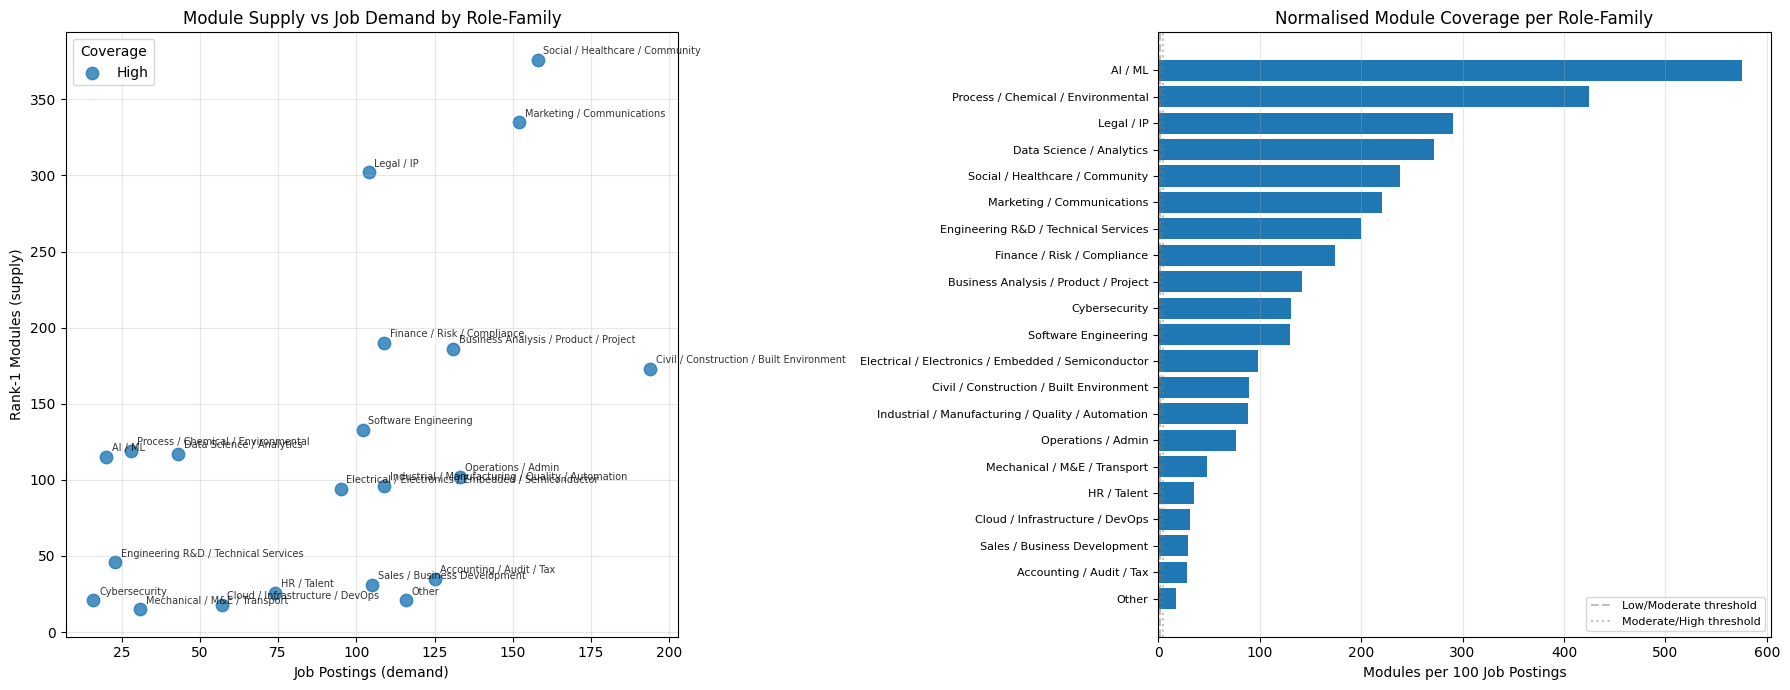

In [47]:
# Scatter plot: job demand vs module supply, coloured by coverage label
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Left: scatter of demand vs supply ---
ax = axes[0]
colors = {"Very Low": "#d62728", "Low": "#ff7f0e", "Moderate": "#2ca02c", "High": "#1f77b4"}
for label, grp in coverage.groupby("coverage_label", observed=True):
    ax.scatter(grp["job_count"], grp["module_count"], label=label, s=80, c=colors.get(label, "grey"), alpha=0.8)
    for idx, row in grp.iterrows():
        ax.annotate(idx, (row["job_count"], row["module_count"]), fontsize=7, alpha=0.8,
                     xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("Job Postings (demand)")
ax.set_ylabel("Rank-1 Modules (supply)")
ax.set_title("Module Supply vs Job Demand by Role-Family")
ax.legend(title="Coverage")
ax.grid(True, alpha=0.3)

# --- Right: horizontal bar of modules_per_100_jobs ---
ax2 = axes[1]
bar_colors = [colors.get(lbl, "grey") for lbl in coverage["coverage_label"]]
ax2.barh(range(len(coverage)), coverage["modules_per_100_jobs"], color=bar_colors)
ax2.set_yticks(range(len(coverage)))
ax2.set_yticklabels(coverage.index, fontsize=8)
ax2.set_xlabel("Modules per 100 Job Postings")
ax2.set_title("Normalised Module Coverage per Role-Family")
ax2.axvline(x=2.0, color="grey", linestyle="--", alpha=0.5, label="Low/Moderate threshold")
ax2.axvline(x=5.0, color="grey", linestyle=":", alpha=0.5, label="Moderate/High threshold")
ax2.legend(fontsize=8)
ax2.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Skill-Level Gap: Demanded Skills Not Covered by Modules
For each role-family, compare the top skills demanded by job postings against the skills supplied by degree modules (from `degree_skill_supply.csv`).

In [48]:
# All skills that appear in degree_skill_supply (the university can teach these)
university_skills = set(degree_skill["skill"].str.lower().str.strip().dropna().unique())
print(f"Total unique skills supplied by NUS degrees: {len(university_skills)}")

# For each role-family: top demanded skills + which are NOT in university supply
gap_rows = []
for fam in coverage.index:
    fam_skills_series = job_skills[job_skills["role_family_name"] == fam]["skill"].value_counts()
    top_demanded = fam_skills_series.head(20)
    for skill, count in top_demanded.items():
        gap_rows.append({
            "role_family": fam,
            "skill": skill,
            "demand_mentions": count,
            "supplied_by_uni": skill in university_skills,
        })

gap_df = pd.DataFrame(gap_rows)
gap_df["coverage_status"] = gap_df["supplied_by_uni"].map({True: "Covered", False: "GAP"})

# Summary: fraction of top-20 demanded skills covered per role-family
gap_summary = gap_df.groupby("role_family").agg(
    top20_skills=("skill", "count"),
    covered=("supplied_by_uni", "sum"),
).assign(
    gap_count=lambda x: x["top20_skills"] - x["covered"],
    pct_covered=lambda x: (x["covered"] / x["top20_skills"] * 100).round(1),
).sort_values("pct_covered", ascending=True)

print("\n=== Skill-Level Coverage: % of top-20 demanded skills supplied by NUS ===")
display(gap_summary)

Total unique skills supplied by NUS degrees: 824

=== Skill-Level Coverage: % of top-20 demanded skills supplied by NUS ===


,top20_skills,covered,gap_count,pct_covered
role_family,,,,
Business Analysis / Product / Project,20,7,13,35.0
Cloud / Infrastructure / DevOps,20,7,13,35.0
Social / Healthcare / Community,20,7,13,35.0
Finance / Risk / Compliance,20,8,12,40.0
Accounting / Audit / Tax,20,9,11,45.0
Operations / Admin,20,9,11,45.0
HR / Talent,20,10,10,50.0
Civil / Construction / Built Environment,20,10,10,50.0
Cybersecurity,20,10,10,50.0


In [49]:
# Show the actual GAP skills for under-covered role-families
under_covered = gap_summary[gap_summary["pct_covered"] < 70].index.tolist()
print(f"Role-families with <70% skill coverage ({len(under_covered)}):\n")

for fam in under_covered:
    gaps = gap_df[(gap_df["role_family"] == fam) & (~gap_df["supplied_by_uni"])].sort_values("demand_mentions", ascending=False)
    if len(gaps) > 0:
        print(f"  {fam}:")
        for _, row in gaps.iterrows():
            print(f"    - {row['skill']} ({row['demand_mentions']} mentions)")
        print()

Role-families with <70% skill coverage (21):

  Business Analysis / Product / Project:
    - communication skills (109 mentions)
    - team player (96 mentions)
    - interpersonal skills (96 mentions)
    - microsoft excel (50 mentions)
    - problem solving (36 mentions)
    - microsoft office (25 mentions)
    - leadership (24 mentions)
    - able to work independently (21 mentions)
    - business requirements (20 mentions)
    - business analyst (18 mentions)
    - management skills (17 mentions)
    - uat (16 mentions)
    - attention to detail (15 mentions)

  Cloud / Infrastructure / DevOps:
    - team player (42 mentions)
    - interpersonal skills (38 mentions)
    - communication skills (37 mentions)
    - troubleshooting (21 mentions)
    - technical support (18 mentions)
    - problem solving (16 mentions)
    - azure (14 mentions)
    - kubernetes (12 mentions)
    - windows server (11 mentions)
    - ansible (11 mentions)
    - docker (10 mentions)
    - active directory 

## 6. Summary Heatmap: Role-Family Readiness
Combine module supply, job demand, mean role score, and skill coverage into a single heatmap.

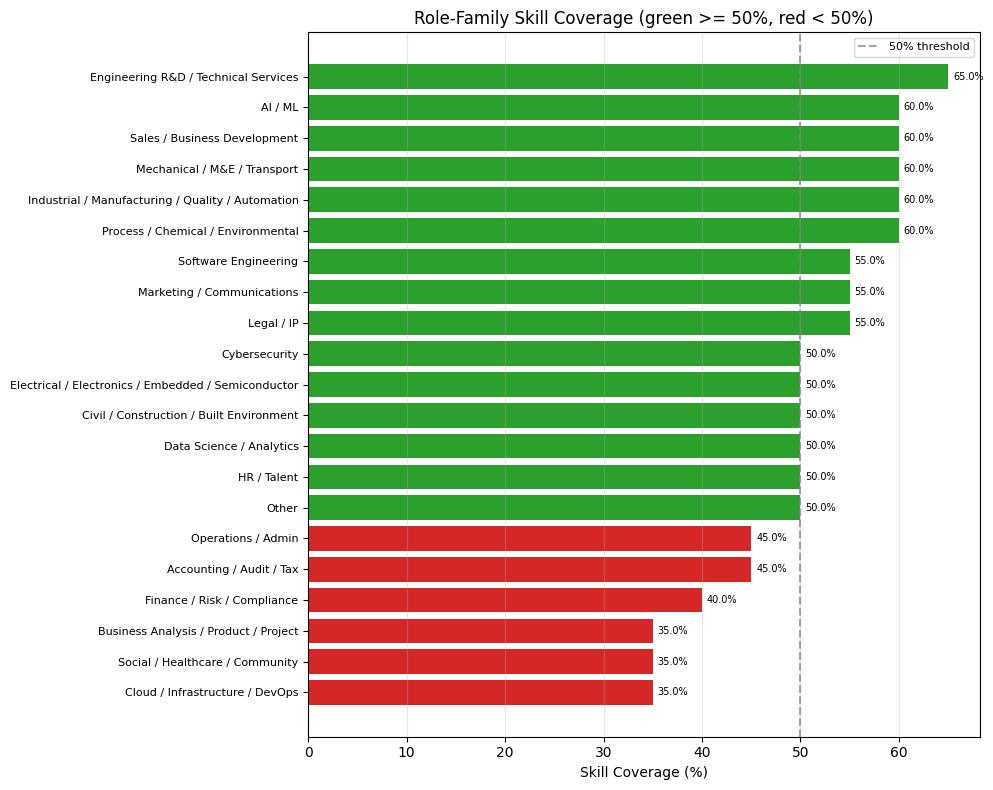

In [50]:
# Build a combined readiness table using skill coverage as the determining factor
readiness = coverage[["job_count", "module_count", "mean_role_score", "modules_per_100_jobs"]].copy()
readiness = readiness.join(gap_summary[["pct_covered"]].rename(columns={"pct_covered": "skill_pct_covered"}), how="left")
readiness["skill_pct_covered"] = readiness["skill_pct_covered"].fillna(0)
readiness = readiness.sort_values("skill_pct_covered", ascending=True)

# Bar chart: skill coverage % per role-family, threshold at 50%
fig, ax = plt.subplots(figsize=(10, max(8, len(readiness) * 0.38)))
bar_colors = ["#2ca02c" if v >= 50 else "#d62728" for v in readiness["skill_pct_covered"]]
ax.barh(range(len(readiness)), readiness["skill_pct_covered"], color=bar_colors)
ax.set_yticks(range(len(readiness)))
ax.set_yticklabels(readiness.index, fontsize=8)
ax.set_xlabel("Skill Coverage (%)")
ax.set_title("Role-Family Skill Coverage (green >= 50%, red < 50%)")
ax.axvline(x=50, color="grey", linestyle="--", alpha=0.7, label="50% threshold")
ax.legend(fontsize=8)
ax.grid(True, axis="x", alpha=0.3)

for i, (_, row) in enumerate(readiness.iterrows()):
    ax.text(row["skill_pct_covered"] + 0.5, i, f"{row['skill_pct_covered']:.1f}%", va="center", fontsize=7)

plt.tight_layout()
plt.show()

In [51]:
# Final classification: skill_pct_covered >= 50% = well-covered, else under-covered
well_covered = readiness[readiness["skill_pct_covered"] >= 50].sort_values("skill_pct_covered", ascending=False)
under_covered = readiness[readiness["skill_pct_covered"] < 50].sort_values("skill_pct_covered", ascending=True)

print("=" * 70)
print(f"WELL-COVERED role-families ({len(well_covered)}):")
print("=" * 70)
for fam, row in well_covered.iterrows():
    print(f"  {fam:45s}  modules={row['module_count']:3.0f}  jobs={row['job_count']:5.0f}  "
          f"skill_cvg={row['skill_pct_covered']:5.1f}%")

print(f"\n{'=' * 70}")
print(f"UNDER-COVERED role-families ({len(under_covered)}):")
print("=" * 70)
for fam, row in under_covered.iterrows():
    print(f"  {fam:45s}  modules={row['module_count']:3.0f}  jobs={row['job_count']:5.0f}  "
          f"skill_cvg={row['skill_pct_covered']:5.1f}%")

WELL-COVERED role-families (15):
  Engineering R&D / Technical Services           modules= 46  jobs=   23  skill_cvg= 65.0%
  Process / Chemical / Environmental             modules=119  jobs=   28  skill_cvg= 60.0%
  Industrial / Manufacturing / Quality / Automation  modules= 96  jobs=  109  skill_cvg= 60.0%
  Mechanical / M&E / Transport                   modules= 15  jobs=   31  skill_cvg= 60.0%
  Sales / Business Development                   modules= 31  jobs=  105  skill_cvg= 60.0%
  AI / ML                                        modules=115  jobs=   20  skill_cvg= 60.0%
  Legal / IP                                     modules=302  jobs=  104  skill_cvg= 55.0%
  Marketing / Communications                     modules=335  jobs=  152  skill_cvg= 55.0%
  Software Engineering                           modules=133  jobs=  102  skill_cvg= 55.0%
  Other                                          modules= 21  jobs=  116  skill_cvg= 50.0%
  HR / Talent                                    modu

## 7. Best Degrees for Each Role-Family
Which NUS degree programmes best prepare students for each role-family, based on how many of their required modules align with that role-family?

In [52]:
# Load degree-module mapping (each row = one module in a degree's curriculum)
deg_mod = pd.read_csv(OUTPUT_DIR / "degree_module_map.csv", low_memory=False)
deg_mod = deg_mod[deg_mod["module_found"] == True].copy()

# Exclude Education / Training
deg_mod = deg_mod[~deg_mod["top_role_family_name"].isin(EXCLUDE_FAMILIES)]

# For each (degree, role_family): count aligned modules and average role score
degree_role = (
    deg_mod.groupby(["degree_id", "major", "faculty", "top_role_family_name"])
    .agg(
        aligned_modules=("module_code", "nunique"),
        mean_role_score=("top_role_score", "mean"),
    )
    .reset_index()
)

# Total modules per degree (for computing share)
degree_total = deg_mod.groupby("degree_id")["module_code"].nunique().rename("total_modules").reset_index()
degree_role = degree_role.merge(degree_total, on="degree_id", how="left")
degree_role["aligned_share"] = (degree_role["aligned_modules"] / degree_role["total_modules"] * 100).round(1)

# For each role-family, show top 5 degrees by number of aligned modules
print("=== Top degrees for each role-family (by # aligned modules) ===\n")

for fam in readiness.sort_values("skill_pct_covered", ascending=False).index:
    fam_degrees = (
        degree_role[degree_role["top_role_family_name"] == fam]
        .sort_values(["aligned_modules", "mean_role_score"], ascending=[False, False])
        .head(5)
    )
    if len(fam_degrees) == 0:
        continue
    print(f"--- {fam} ---")
    for _, d in fam_degrees.iterrows():
        print(f"  {d['faculty']:5s} | {d['major']:40s}  "
              f"aligned={d['aligned_modules']:3.0f}/{d['total_modules']:3.0f} ({d['aligned_share']:4.1f}%)  "
              f"avg_score={d['mean_role_score']:.3f}")
    print()

=== Top degrees for each role-family (by # aligned modules) ===

--- Engineering R&D / Technical Services ---
  College of Design and Engineering | Materials Science and Engineering         aligned= 46/2551 ( 1.8%)  avg_score=0.406
  College of Humanities and Sciences | Chemistry with Specialisation in Chemical Research  aligned= 46/2551 ( 1.8%)  avg_score=0.406
  College of Humanities and Sciences | Chemistry with Specialisation in Sustainable Chemistry  aligned= 46/2551 ( 1.8%)  avg_score=0.406
  College of Design and Engineering | Biomedical Engineering                    aligned= 46/2551 ( 1.8%)  avg_score=0.406
  College of Humanities and Sciences | Chemistry                                 aligned= 46/2551 ( 1.8%)  avg_score=0.405

--- AI / ML ---
  School of Computing | Computer Science                          aligned=115/2551 ( 4.5%)  avg_score=0.453
  School of Computing | Information Security                      aligned=115/2551 ( 4.5%)  avg_score=0.451
  School of Computin

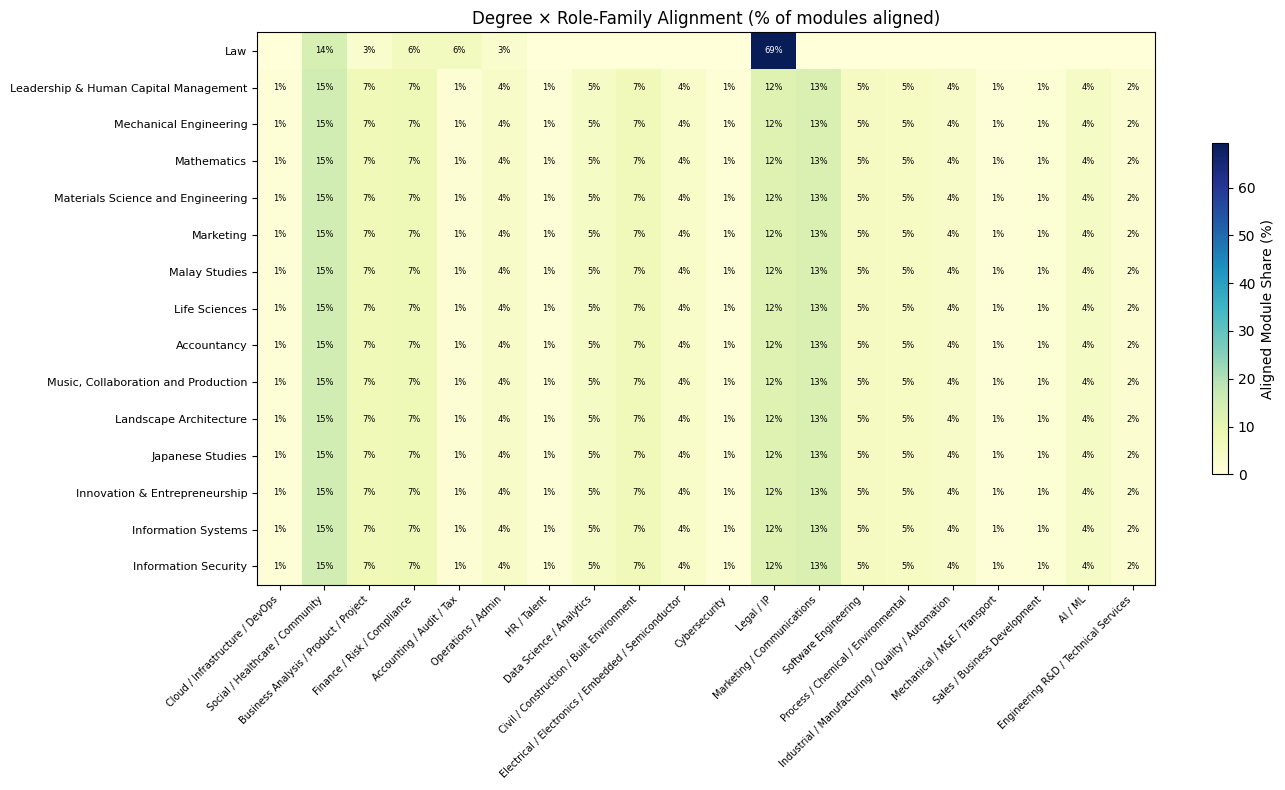

In [53]:
# Heatmap: top 15 degrees x role-families (by aligned module share)
# Pivot to get a matrix of aligned_share per (degree, role_family)
pivot = degree_role.pivot_table(
    index="major", columns="top_role_family_name",
    values="aligned_share", aggfunc="max", fill_value=0,
)

# Keep only role-families in our analysis
role_fams_in_analysis = [f for f in readiness.index if f in pivot.columns]
pivot = pivot[role_fams_in_analysis]

# Select top 15 degrees by max aligned share across any role-family
top_degrees = pivot.max(axis=1).sort_values(ascending=False).head(15).index
pivot_top = pivot.loc[top_degrees]

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(pivot_top.values, aspect="auto", cmap="YlGnBu", vmin=0)

ax.set_xticks(range(len(pivot_top.columns)))
ax.set_xticklabels(pivot_top.columns, rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(len(pivot_top)))
ax.set_yticklabels(pivot_top.index, fontsize=8)

for i in range(len(pivot_top)):
    for j in range(len(pivot_top.columns)):
        val = pivot_top.iloc[i, j]
        if val > 0:
            ax.text(j, i, f"{val:.0f}%", ha="center", va="center", fontsize=6,
                    color="white" if val > 20 else "black")

ax.set_title("Degree × Role-Family Alignment (% of modules aligned)")
plt.colorbar(im, ax=ax, shrink=0.6, label="Aligned Module Share (%)")
plt.tight_layout()
plt.show()

In [31]:
# Diagnostic: Why does "Education / Training" look so positive?
EDU_FAM = [f for f in coverage.index if "ducation" in f or "raining" in f]
print("Matching role-family names:", EDU_FAM)

for fam in EDU_FAM:
    print(f"\n{'='*70}")
    print(f"DIAGNOSTIC FOR: {fam}")
    print(f"{'='*70}")

    # 1. Raw coverage numbers
    row = coverage.loc[fam]
    print(f"\n  job_count:          {row['job_count']:.0f}")
    print(f"  module_count:       {row['module_count']:.0f}")
    print(f"  modules_per_100_jobs: {row['modules_per_100_jobs']}")
    print(f"  mean_role_score:    {row['mean_role_score']:.4f}")
    print(f"  coverage_label:     {row['coverage_label']}")

    # 2. Which modules are rank-1 for this family?
    edu_modules = top1[top1["role_family_name"] == fam][["module_code", "module_title", "role_score", "evidence_job_count"]].sort_values("role_score", ascending=False)
    print(f"\n  Rank-1 modules ({len(edu_modules)}):")
    for _, m in edu_modules.iterrows():
        print(f"    {m['module_code']:10s} {m['module_title'][:50]:50s}  score={m['role_score']:.4f}  evidence_jobs={m['evidence_job_count']:.0f}")

    # 3. Skill coverage detail
    fam_gaps = gap_df[gap_df["role_family"] == fam].sort_values("demand_mentions", ascending=False)
    print(f"\n  Top-20 demanded skills (covered={fam_gaps['supplied_by_uni'].sum():.0f}, gap={len(fam_gaps) - fam_gaps['supplied_by_uni'].sum():.0f}):")
    for _, g in fam_gaps.iterrows():
        status = "OK" if g["supplied_by_uni"] else "GAP"
        print(f"    [{status:3s}] {g['skill']:35s} ({g['demand_mentions']} mentions)")

    # 4. Normalised scores in heatmap
    if fam in readiness_norm.index:
        nr = readiness_norm.loc[fam]
        print(f"\n  Normalised heatmap values:")
        print(f"    module_count:       {nr['module_count']:.3f}")
        print(f"    mean_role_score:    {nr['mean_role_score']:.3f}")
        print(f"    modules_per_100_jobs:{nr['modules_per_100_jobs']:.3f}")
        print(f"    skill_pct_covered:  {nr['skill_pct_covered']:.3f}")
        print(f"    avg_readiness:      {nr['avg_readiness']:.3f}")

Matching role-family names: ['Education / Training']

DIAGNOSTIC FOR: Education / Training

  job_count:          69
  module_count:       1201
  modules_per_100_jobs: 1740.6
  mean_role_score:    0.4191
  coverage_label:     High

  Rank-1 modules (1201):
    UTOR2001   Undergraduate Teaching Opportunities Programme      score=0.6715  evidence_jobs=50
    UTOS2201   Undergraduate Teaching Opportunities Programme (UT  score=0.6689  evidence_jobs=50
    UTOD2001   Undergraduate Teaching Opportunities Programme (UT  score=0.6689  evidence_jobs=50
    UTOA2001CL Undergraduate Teaching Opportunities Programme (UT  score=0.6689  evidence_jobs=50
    UTOA2001E  Undergraduate Teaching Opportunities Programme (UT  score=0.6689  evidence_jobs=50
    UTOA2001H  Undergraduate Teaching Opportunities Programme (UT  score=0.6689  evidence_jobs=50
    UTOA2001J  Undergraduate Teaching Opportunities Programme (UT  score=0.6689  evidence_jobs=50
    UTOA2001P  Undergraduate Teaching Opportunities Progr